**STOCK-TREND PREDICTION**

1. Data Loading and Summary


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [5]:
# Load CSV
df = pd.read_csv("/content/data.csv")
df


,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.20
1,2000-01-04,1594.40,1641.95,1594.40,1638.70
2,2000-01-05,1634.55,1635.50,1555.05,1595.80
3,2000-01-06,1595.80,1639.00,1595.80,1617.60
4,2000-01-07,1616.60,1628.25,1597.20,1613.30
...,...,...,...,...,...
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70
6313,2025-05-23,24639.50,24909.05,24614.05,24853.15


In [6]:
print(f"Total number of records present in above dataset:{df.shape[0]}")
print(f"Total number of records present in above dataset:{df.shape[1]}")

Total number of records present in above dataset:6315
Total number of records present in above dataset:5


In [7]:
df.head()

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.2
1,2000-01-04,1594.40,1641.95,1594.40,1638.7
2,2000-01-05,1634.55,1635.50,1555.05,1595.8
3,2000-01-06,1595.80,1639.00,1595.80,1617.6
4,2000-01-07,1616.60,1628.25,1597.20,1613.3


In [8]:
df.tail()

,Date,Open,High,Low,Close
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70
6313,2025-05-23,24639.50,24909.05,24614.05,24853.15
6314,2025-05-26,24919.35,25079.20,24900.50,25001.15


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6315 entries, 0 to 6314
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6315 non-null   object 
 1   Open    6315 non-null   float64
 2   High    6315 non-null   float64
 3   Low     6315 non-null   float64
 4   Close   6315 non-null   float64
dtypes: float64(4), object(1)
memory usage: 246.8+ KB


In [10]:
df.describe(include='all')

,Date,Open,High,Low,Close
count,6315,6315.000000,6315.000000,6315.000000,6315.000000
unique,6315,NaN,NaN,NaN,NaN
top,2025-05-26,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,7813.645732,7858.810665,7758.153325,7809.684806
std,NaN,6248.404053,6270.434420,6216.988574,6244.654057
min,NaN,853.000000,877.000000,849.950000,854.200000
25%,NaN,2851.375000,2884.100000,2812.650000,2850.600000
50%,NaN,5803.050000,5857.350000,5749.500000,5796.900000
75%,NaN,10786.175000,10830.625000,10727.775000,10781.725000


2. Data Preprocessing

In [11]:
df.isnull().sum()
df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates()

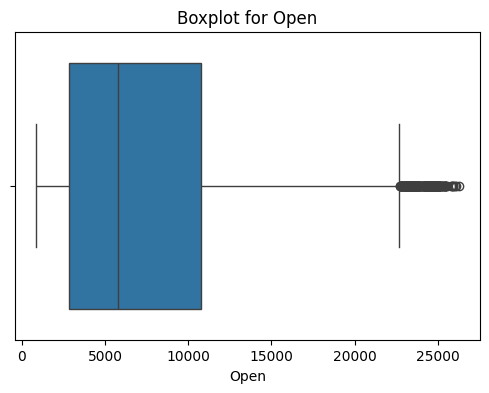

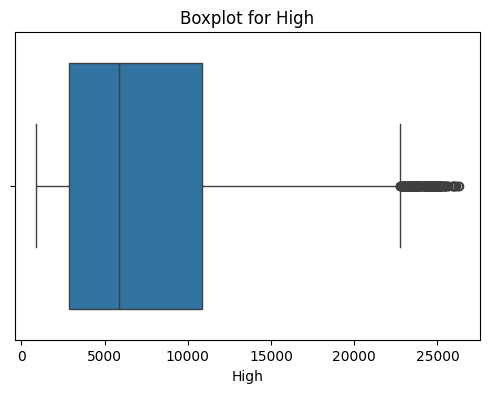

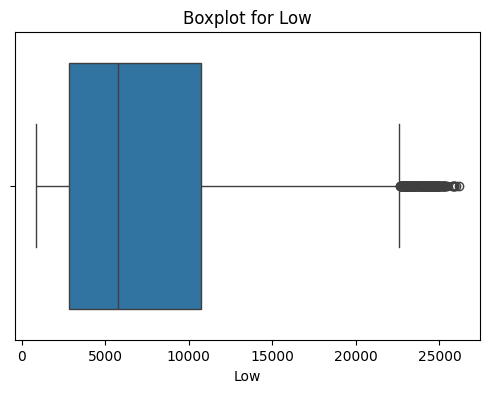

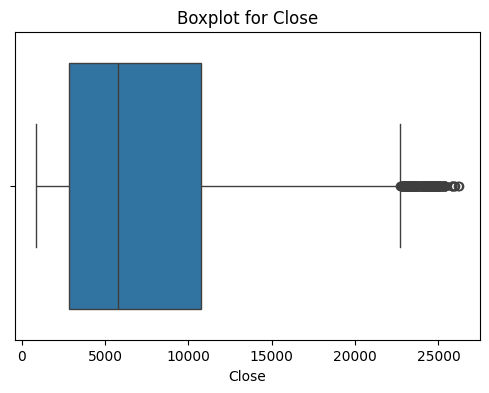

After removing outliers:
               Open          High           Low         Close
count   6081.000000   6081.000000   6081.000000   6081.000000
mean    7185.559456   7228.139813   7133.292304   7181.991465
std     5465.605945   5483.758292   5438.183703   5462.304818
min      853.000000    877.000000    849.950000    854.200000
25%     2721.200000   2787.300000   2683.200000   2733.900000
50%     5642.050000   5689.900000   5595.500000   5640.000000
75%    10345.150000  10396.000000  10285.500000  10335.300000
max    22677.400000  22726.450000  22567.850000  22666.300000


In [12]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

#Remove outliers using IQR (Interquartile Range) method
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

#  Verify after removal
print("After removing outliers:")
print(df.describe())

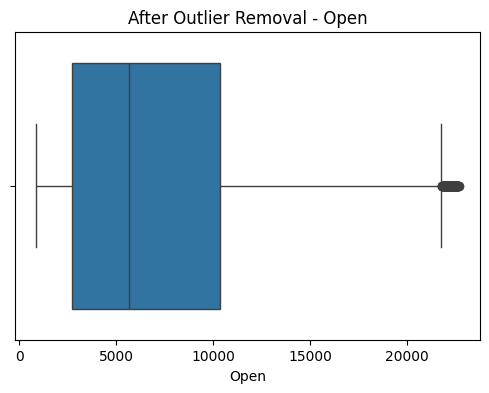

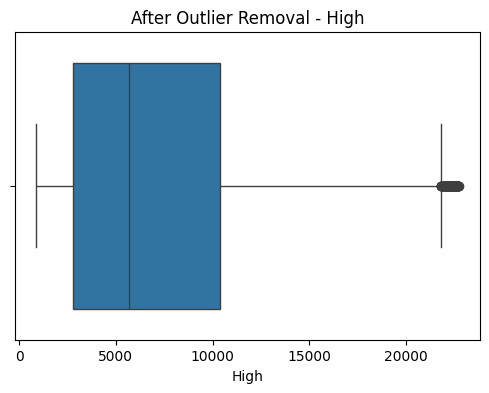

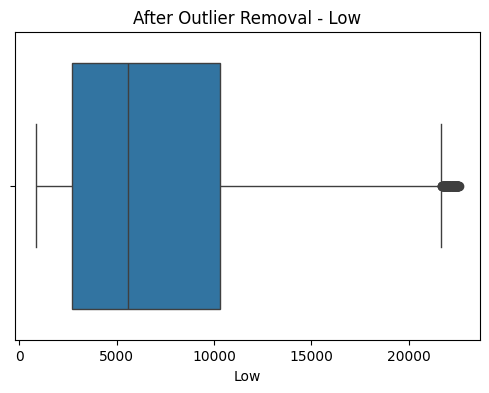

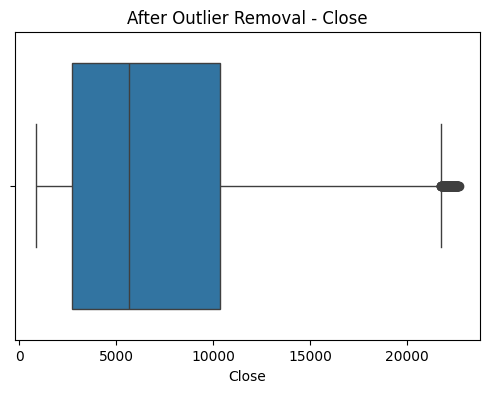

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"After Outlier Removal - {col}")
    plt.show()

3. Exploratory Data Analysis (EDA)

In [14]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.head())

(6081, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 6081 entries, 0 to 6285
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6081 non-null   object 
 1   Open    6081 non-null   float64
 2   High    6081 non-null   float64
 3   Low     6081 non-null   float64
 4   Close   6081 non-null   float64
dtypes: float64(4), object(1)
memory usage: 285.0+ KB
None
               Open          High           Low         Close
count   6081.000000   6081.000000   6081.000000   6081.000000
mean    7185.559456   7228.139813   7133.292304   7181.991465
std     5465.605945   5483.758292   5438.183703   5462.304818
min      853.000000    877.000000    849.950000    854.200000
25%     2721.200000   2787.300000   2683.200000   2733.900000
50%     5642.050000   5689.900000   5595.500000   5640.000000
75%    10345.150000  10396.000000  10285.500000  10335.300000
max    22677.400000  22726.450000  22567.850000  22666.300000
         Date

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:", num_cols)

Numerical Columns: Index(['Open', 'High', 'Low', 'Close'], dtype='object')


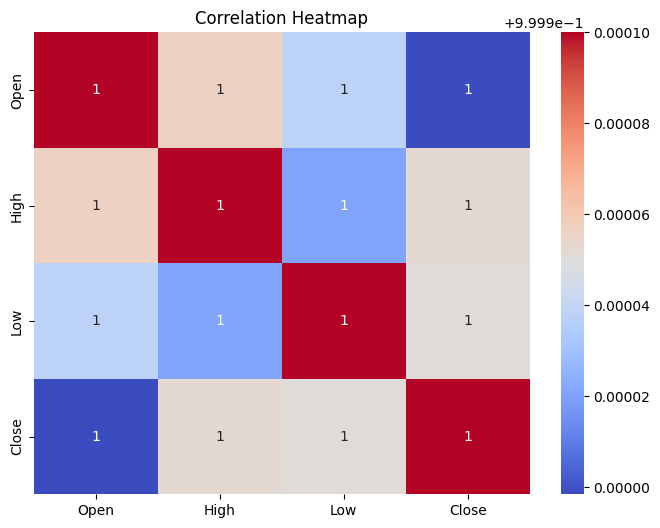

In [16]:
#Correlation Analysis
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

AttributeError: 'DataFrame' object has no attribute 'show'

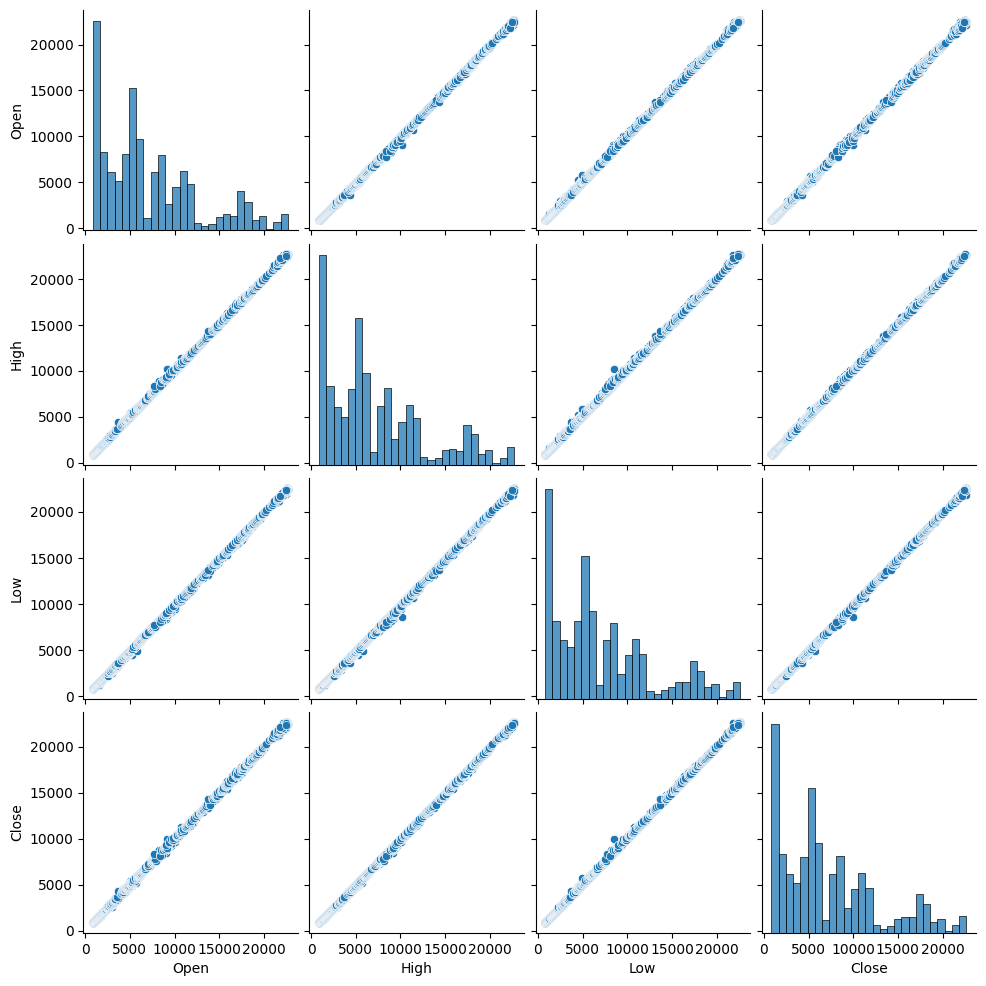

In [17]:
#Pairplot
sns.pairplot(df[num_cols])
df.show()

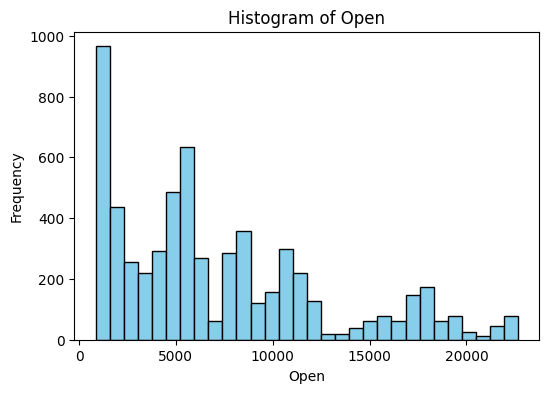

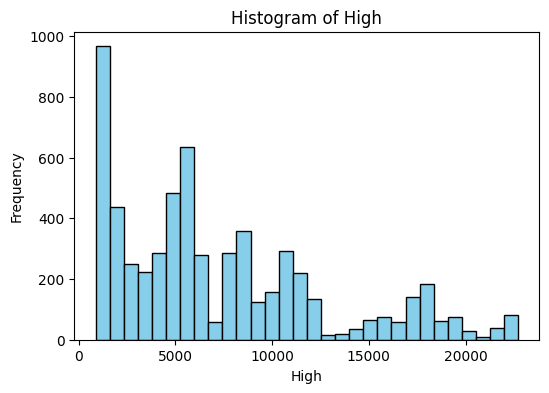

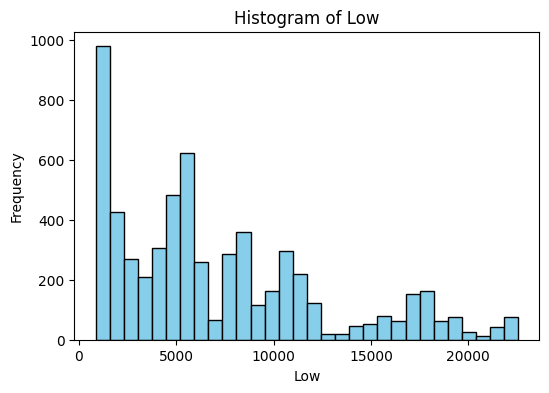

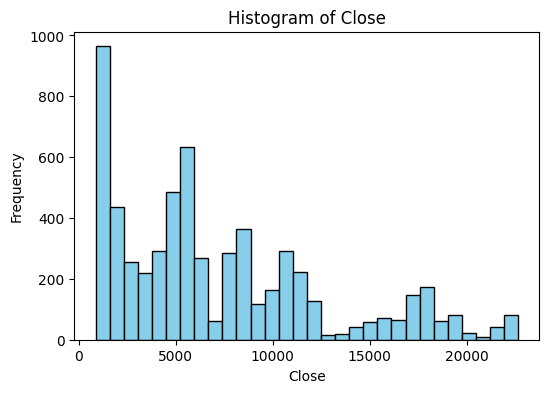

In [18]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

4. Model Building

In [22]:
X = df[['Open', 'High', 'Low']]
y = df['Close']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)

R² Score: 0.9998084386572385
RMSE: 50.54266793489687


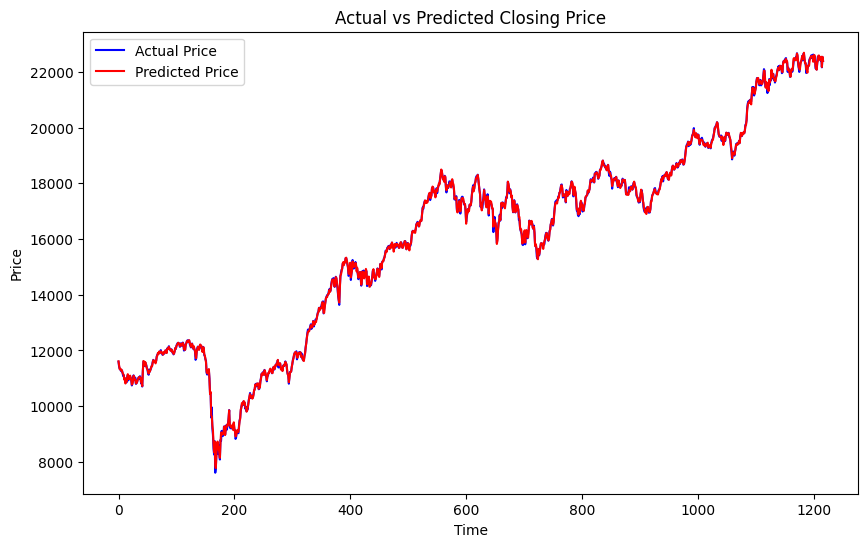

In [27]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red')
plt.title('Actual vs Predicted Closing Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5

print("Model Performance:")
print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 4))
print("RMSE     :", round(rmse, 4))

Model Performance:
R² Score : 0.9998
MAE      : 37.0892
RMSE     : 50.5427


In [29]:
accuracy = (1 - (mae / y_test.mean())) * 100
print("Approx. Accuracy: ", round(accuracy, 2), "%")

Approx. Accuracy:  99.77 %
